<a href="https://colab.research.google.com/github/antoniovfonseca/agentic-ai-global-lulc/blob/main/notebooks/quest-gee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Environment Setup

First, we will import the necessary libraries to handle spatial data processing.

In [1]:
# Install dependency
!pip install geemap -q > /dev/null 2>&1
!apt-get install -y gdal-bin -q > /dev/null 2>&1
!pip install matplotlib-scalebar -q > /dev/null 2>&1

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.1 Import libraries and GitHub repository

In [59]:
# Import libraries
import pandas as pd
import os
import sys
import geemap


# Define repository details
repo_url = 'https://github.com/antoniovfonseca/agentic-ai-global-lulc.git'
repo_name = 'agentic-ai-global-lulc'

# Clone or update the repository
if not os.path.exists(repo_name):
    print(f"Cloning {repo_name}...")
    !git clone {repo_url}
else:
    print(f"Updating {repo_name}...")
    !cd {repo_name} && git pull

# Add the notebooks directory to system path to allow imports
notebooks_path = os.path.join(repo_name, 'notebooks')
if notebooks_path not in sys.path:
    sys.path.append(os.path.abspath(notebooks_path))
    print(f"Added {notebooks_path} to system path.")

import importlib
import utils

importlib.reload(utils)
print("Utils module loaded successfully.")

Updating agentic-ai-global-lulc...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 769 bytes | 109.00 KiB/s, done.
From https://github.com/antoniovfonseca/agentic-ai-global-lulc
   e044ae6..ccf1a71  main       -> origin/main
Updating e044ae6..ccf1a71
Fast-forward
 notebooks/utils.py | 26 +++++++++++++++++++++++++-
 1 file changed, 25 insertions(+), 1 deletion(-)
Added agentic-ai-global-lulc/notebooks to system path.


IndentationError: unindent does not match any outer indentation level (utils.py, line 3295)

## 1.2 Global Configuration

In [34]:
# 1. GEE User
user = 'antfonseca-499920'

# 2. Global Directory Paths
gee_drive_folder = "GLANCE_EU_30m_2001_to_2019"
base_drive_dir = f"/content/drive/MyDrive/{gee_drive_folder}"

# 3. Define the time points
years_to_process = list(range(2001, 2020))
#years_to_process = [2001, 2010, 2019]
#years_to_process = [2002, 2003]

# 4. Define the spatial resolution
spatial_resolution = 300


In [4]:
import ee

# Authenticate and initialize Earth Engine using the global 'user' variable
try:
    ee.Initialize(project=user)
    print(f"Earth Engine initialized successfully for project: {user}")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=user)
    print(f"Earth Engine authenticated and initialized for project: {user}")


Earth Engine authenticated and initialized for project: antfonseca-499920


# 2.GLanCE Visualization

In [ ]:
# Define parameters
target_year = 2019

# Run the function imported from utils.py
glance_map = utils.get_glance_map(target_year)

# Display the map
if glance_map:
    display(glance_map)

# 3.Class Area at Time Points

In [6]:
# Trigger the export tasks via the utils function using global config
print("Starting global pixel count exports via GEE...")
tasks_counts = utils.export_global_pixel_counts_tasks(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution
)

print(f"\nSuccess! {len(tasks_counts)} tasks have been submitted to GEE.")


Starting global pixel count exports via GEE...
Task submitted for year 2001.
Task submitted for year 2002.
Task submitted for year 2003.
Task submitted for year 2004.
Task submitted for year 2005.
Task submitted for year 2006.
Task submitted for year 2007.
Task submitted for year 2008.
Task submitted for year 2009.
Task submitted for year 2010.
Task submitted for year 2011.
Task submitted for year 2012.
Task submitted for year 2013.
Task submitted for year 2014.
Task submitted for year 2015.
Task submitted for year 2016.
Task submitted for year 2017.
Task submitted for year 2018.
Task submitted for year 2019.

Success! 19 tasks have been submitted to GEE.


Generating the bar chart from GEE CSVs...
Chart successfully saved at: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/chart_pixel_per_class_net_change.png


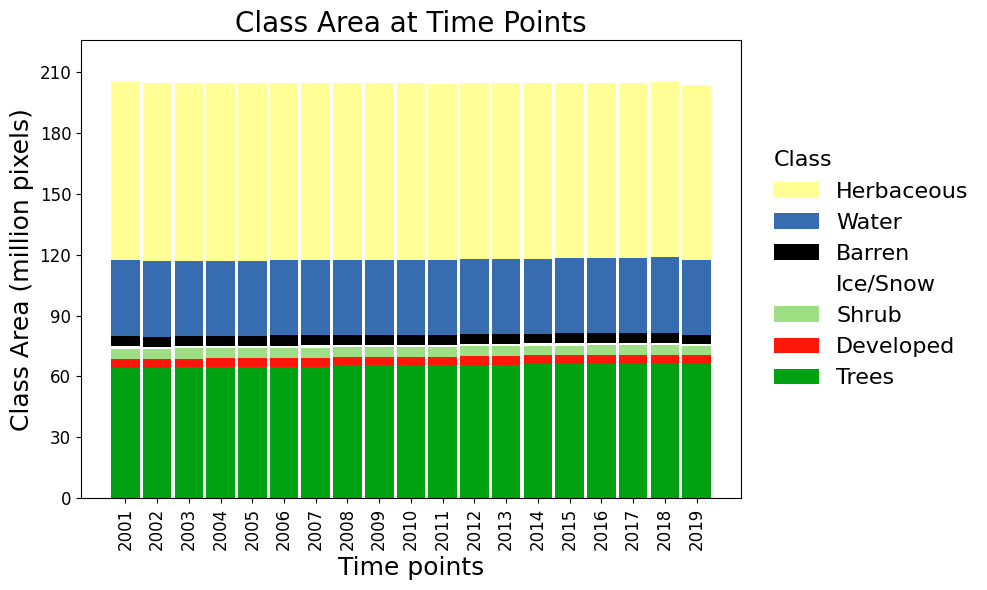

In [15]:
# Call the updated function to generate the plot using global directories
print("Generating the bar chart from GEE CSVs...")
utils.plot_pixel_counts_bar_chart(
    input_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA,
    output_dir=base_drive_dir
)

# 4.Number of Changes

## 4.1 Export compute number of changes task to GEE

In [11]:
# 1. Trigger the tasks for the Number of Changes section using the function from utils.py
print("Submitting Number of Changes Tasks to GEE...")

change_freq_tasks = utils.export_global_change_frequency_tasks(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
)

print(f"\nSuccess! {len(change_freq_tasks)} tasks submitted to GEE.")


Submitting Number of Changes Tasks to GEE...
Task submitted for interval 2002-2003

Success! 1 tasks submitted to GEE.


## 4.2 Plot Number of Changes during Time Intervals chart

Generating the chart from GEE CSVs...


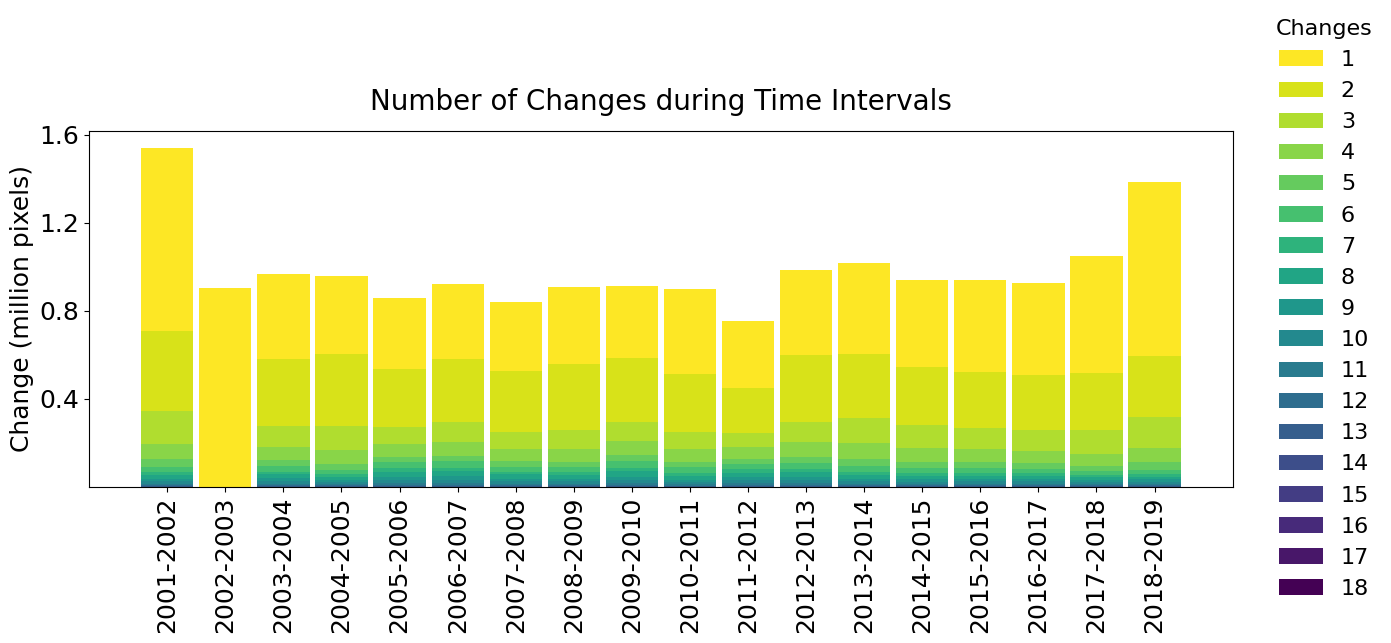

Chart saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/chart_number_change_time_interval.png


In [13]:
# 2. Execute the plotting function reading directly from the Drive folder
# Note: Wait until the GEE tasks finish exporting to run this part!
print("Generating the chart from GEE CSVs...")

utils.plot_global_change_frequency_bar_chart(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
)

## 4.3 Plot Number of Changes Overall

Generating the overall changes distribution chart...


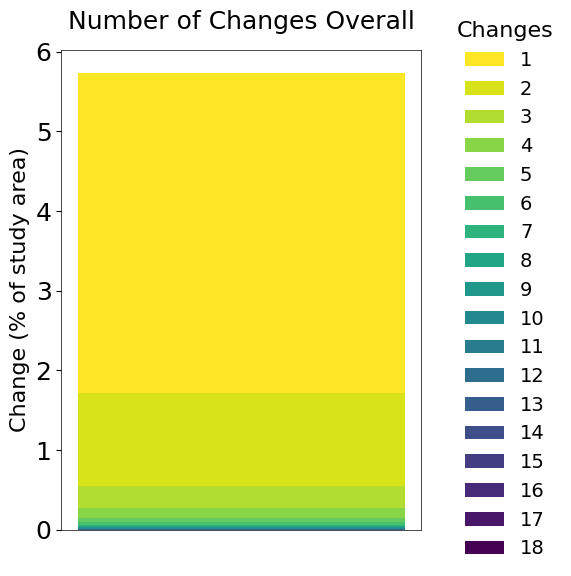

Chart saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/chart_number_changes_percentage_overall.png


In [14]:
print("Generating the overall changes distribution chart...")
utils.plot_number_of_changes_distribution(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
)

## 4.4 Export Number of Changes raster map task to GEE

In [ ]:
import importlib
import utils
importlib.reload(utils)

print("Submitting Number of Changes Raster Task to GEE...")
num_changes_raster_task = utils.export_global_number_of_changes_raster_task(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
)
print("\nSuccess! Raster export task submitted to GEE. Check the Tasks tab.")

## 4.5 Plot Number of Change map

Generating the global Number of Changes map from GEE rasters...


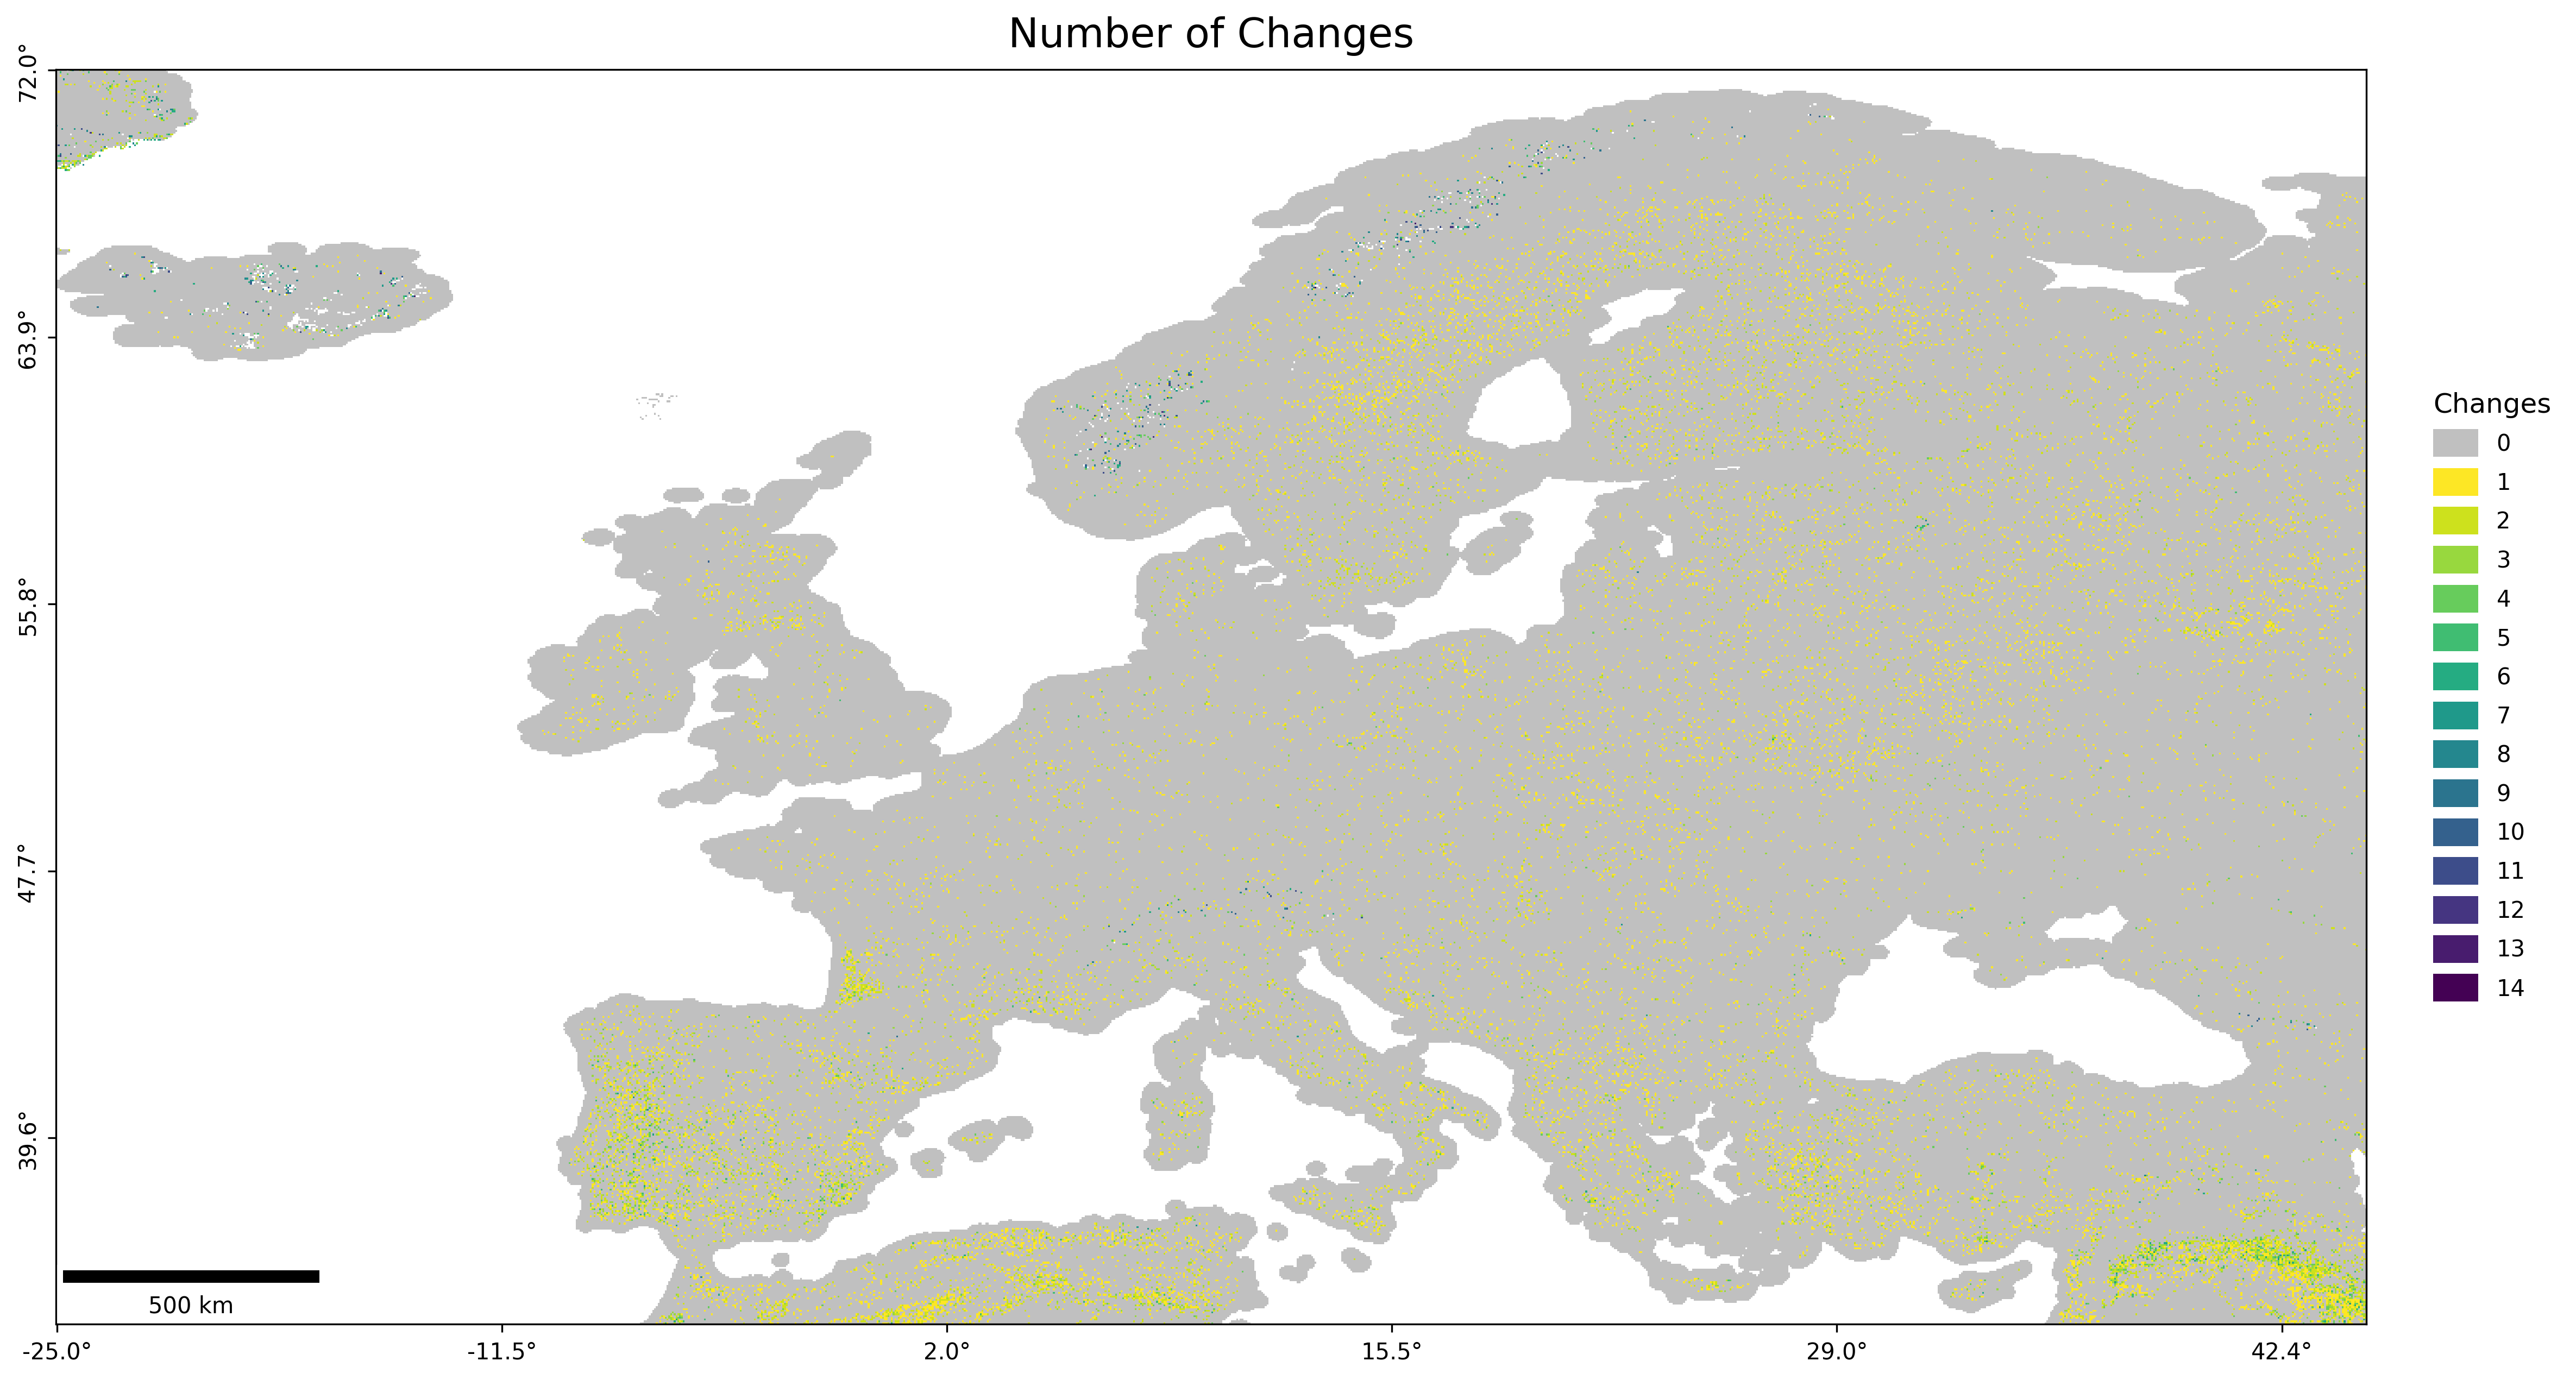

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/maps/map_number_of_changes.png


In [16]:
# Execute the plotting function reading directly from the Drive folder
print("Generating the global Number of Changes map from GEE rasters...")

try:
    utils.plot_number_of_changes_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename="Number_of_Changes_Raster",
        scale_factor=0.05
    )
except Exception as e:
    print(f"\nError running the function: {e}")

# 5.Trajectory Analysis

## 5.1 Export Trajectory raster map taks to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# 1. Execute the trajectory analysis task utilizing the global variables
trajectory_task = utils.export_trajectory_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
    collection_id=utils.GLANCE_COLLECTION_ID,
    band_name=utils.GLANCE_CLASS_BAND,
    nodata_val=utils.NODATA_VALUE,
)

## 5.2 Export compute Trajectories per Time Interval task to GEE

In [8]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the new GEE task
trajectory_intervals_task = utils.export_trajectory_intervals_csv_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
)

Task 'Trajectory_Contributions_2001_2019' submitted to Google Earth Engine.


## 5.3 Plot Trajectory per Time Interval

Loading data from: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/Trajectory_Contributions_2001_2019.csv


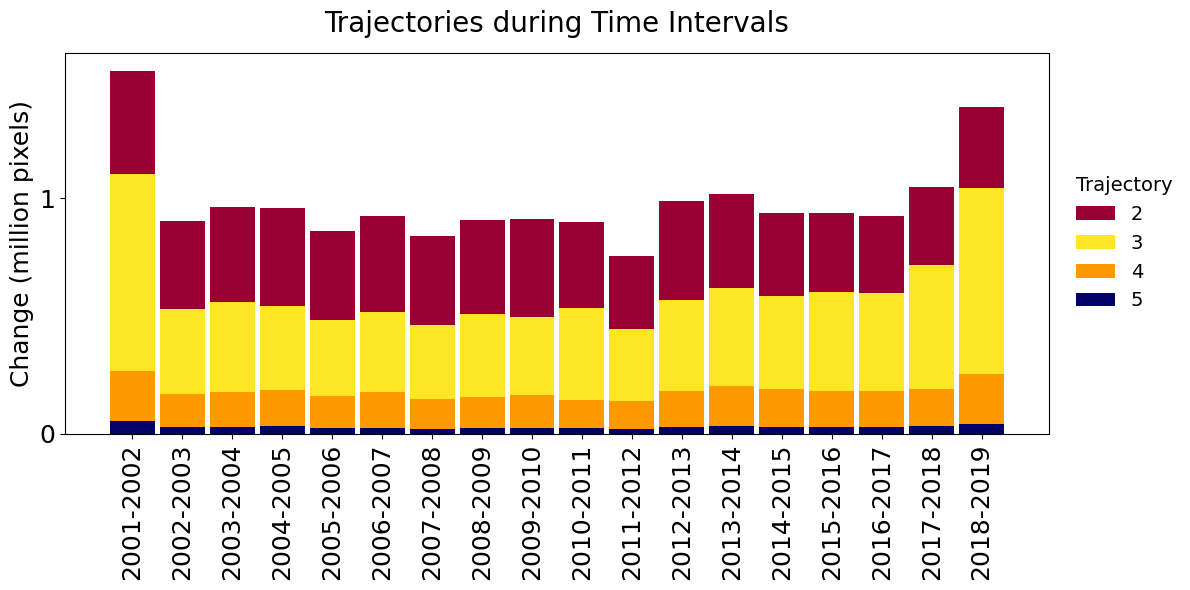

Figure saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/graphic_trajectory_time_interval.png


In [31]:
import os
import pandas as pd
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# 1. Load the CSV exported by the GEE task from Drive
csv_filename = f"Trajectory_Contributions_{years_to_process[0]}_{years_to_process[-1]}.csv"
csv_path = os.path.join(base_drive_dir, csv_filename)

print(f"Loading data from: {csv_path}")

try:
    df_trajectory_intervals = pd.read_csv(csv_path, index_col="Interval")

    # Keep only the relevant trajectory columns (ignore system index or .geo if exported by GEE)
    valid_cols = [col for col in df_trajectory_intervals.columns if col in ['2', '3', '4', '5']]
    df_trajectory_intervals = df_trajectory_intervals[valid_cols]

    # 2. Execute the visualization using the utility function
    utils.plot_trajectory_contributions(
        df=df_trajectory_intervals,
        output_path=base_drive_dir,
    )
except FileNotFoundError:
    print(f"Error: The file {csv_filename} was not found.")
    print("Please ensure the GEE Export Task has finished running before executing this cell.")

## 5.4 Export compute Trajectory overall task to GEE

In [29]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the new GEE task for overall trajectory
trajectory_overall_task = utils.export_trajectory_overall_csv_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
)

Task 'Trajectory_Overall_2001_2019' submitted to Google Earth Engine.


## 5.5 Plot Trajectory Overall chart

Reading total area from: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/Pixel_Counts_LULC_2001.csv
-> Total valid pixels (ignoring 255): 203,475,354

Generating the overall trajectory distribution chart...


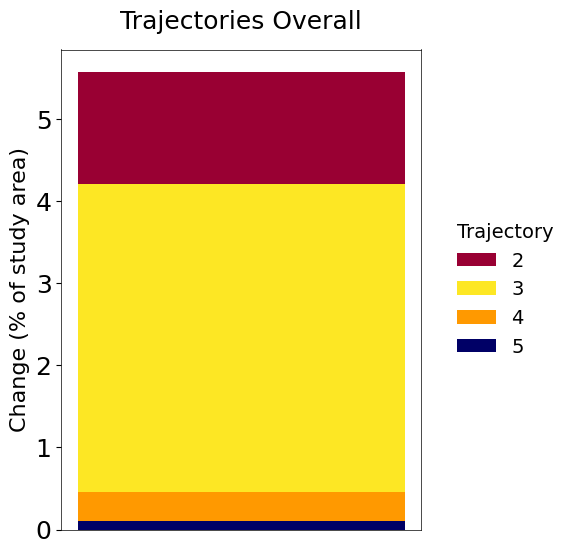

Figure saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/graphic_trajectory_percentage_overall.png


In [30]:
import os
import pandas as pd
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# 1. Discover the total valid area using the pixel count from the initial year
y_start = years_to_process[0]
y_end = years_to_process[-1]
lulc_csv_path = os.path.join(base_drive_dir, f"Pixel_Counts_LULC_{y_start}.csv")

total_valid_pixels = 0
if os.path.exists(lulc_csv_path):
    print(f"Reading total area from: {lulc_csv_path}")
    df_lulc = pd.read_csv(lulc_csv_path)

    # Ignore metadata columns and class 255 (NoData)
    cols_to_ignore = ['system:index', '.geo', 'Period', '255']
    valid_cols = [c for c in df_lulc.columns if c not in cols_to_ignore]

    # Sum the pixels for all valid classes
    total_valid_pixels = df_lulc[valid_cols].sum().sum()
    print(f"-> Total valid pixels (ignoring 255): {total_valid_pixels:,.0f}")
else:
    print(f"Warning: File {lulc_csv_path} not found.")
    print("Cannot calculate the percentage over the total area.")

# 2. Generate the chart with the correct total area
overall_csv_filename = f"Trajectory_Overall_{y_start}_{y_end}.csv"

if total_valid_pixels > 0:
    print("\nGenerating the overall trajectory distribution chart...")
    utils.plot_trajectory_distribution(
        input_dir=base_drive_dir,
        csv_filename=overall_csv_filename,
        total_pixels=total_valid_pixels
    )


## 5.5 Plot Trajectory Map

Generating the global Trajectory map from GEE rasters...


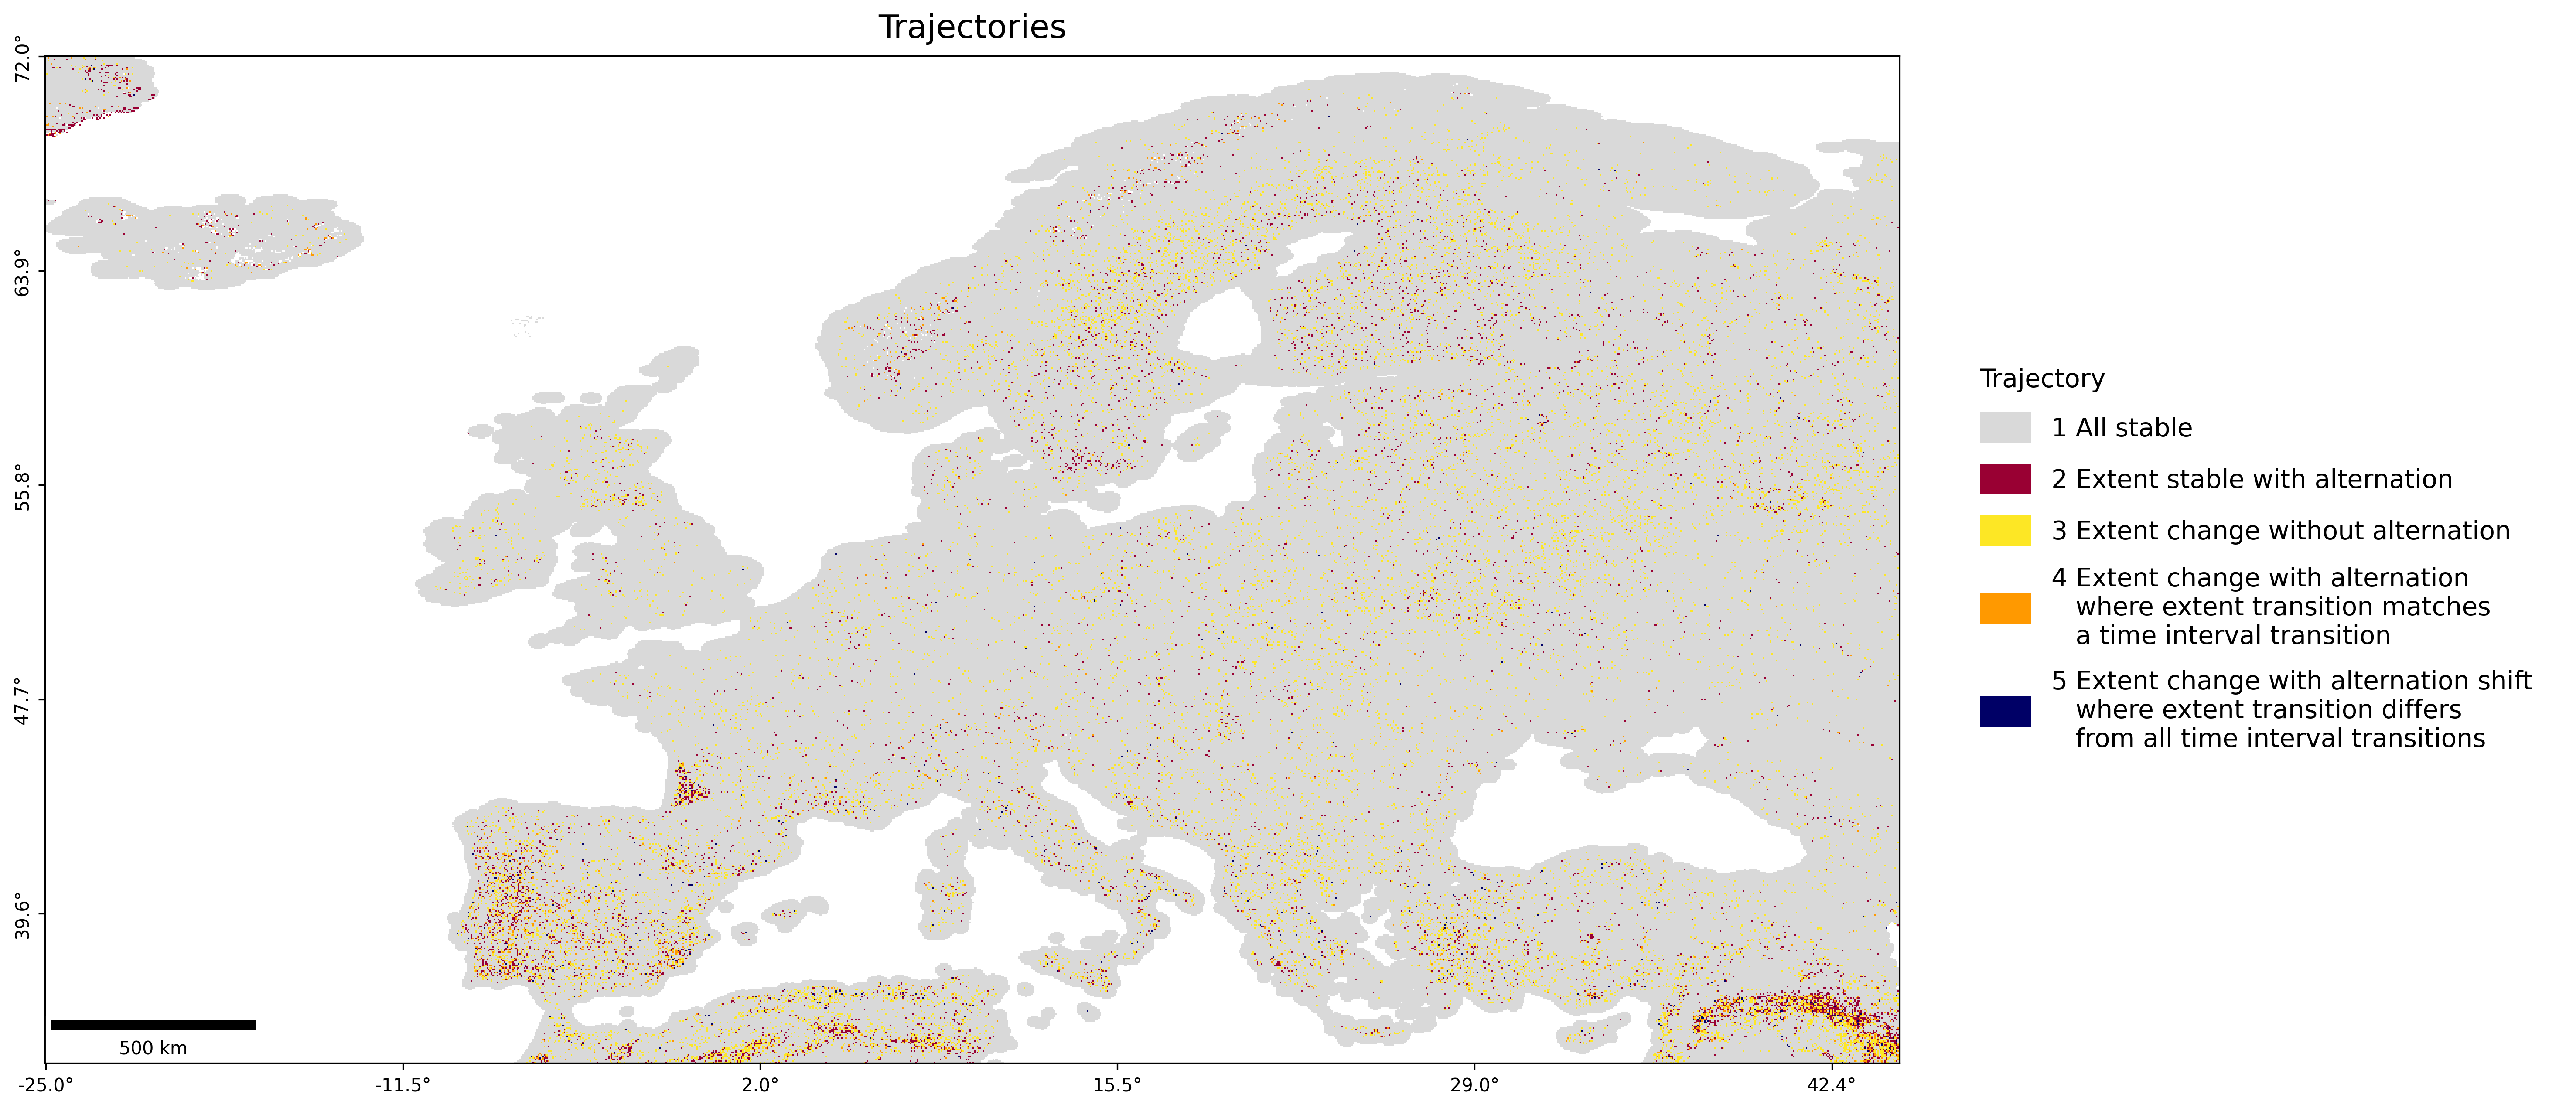

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/maps/map_trajectories.png


In [17]:
import os
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the updated parameters
print("Generating the global Trajectory map from GEE rasters...")
utils.plot_trajectory_map(
    output_dir=base_drive_dir,
    raster_filename="Trajectory_Analysis",
    scale_factor=0.05,
    nodata_val=255
)


# 6.Change Components Analysis

## 6.1 Compute Transition matrix

In [54]:
import importlib
import utils

# Reload utils safely
importlib.reload(utils)

print("Submitting interval transition matrix tasks to GEE...")

# Using the native and already tested function from utils.py
transition_tasks = utils.export_global_transition_tasks(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution
)

print(f"\nSuccess! Submitted {len(transition_tasks)} tasks to GEE. You can check the progress in the Earth Engine Tasks tab.")


Submitting interval transition matrix tasks to GEE...


Task started for transition_2001_2002 (Scale: 300m)
Task started for transition_2002_2003 (Scale: 300m)
Task started for transition_2003_2004 (Scale: 300m)
Task started for transition_2004_2005 (Scale: 300m)
Task started for transition_2005_2006 (Scale: 300m)
Task started for transition_2006_2007 (Scale: 300m)
Task started for transition_2007_2008 (Scale: 300m)
Task started for transition_2008_2009 (Scale: 300m)
Task started for transition_2009_2010 (Scale: 300m)
Task started for transition_2010_2011 (Scale: 300m)
Task started for transition_2011_2012 (Scale: 300m)
Task started for transition_2012_2013 (Scale: 300m)
Task started for transition_2013_2014 (Scale: 300m)
Task started for transition_2014_2015 (Scale: 300m)
Task started for transition_2015_2016 (Scale: 300m)
Task started for transition_2016_2017 (Scale: 300m)
Task started for transition_2017_2018 (Scale: 300m)
Task started for transition_2018_2019 (Scale: 300m)
Task started for transition_2001_2019 (Scale: 300m)

Success! Su

In [64]:
task_unaccounted = utils.export_unaccounted_extent_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
    nodata_val=utils.NODATA_VALUE
)

print(f"-> 1 Unaccounted Extent task submitted (ID: {task_unaccounted.id}).")

Preparing Unaccounted Extent GEE Task for 2001-2019...
Task 'Unaccounted_Extent_2001_2019' submitted to Google Earth Engine.
-> 1 Unaccounted Extent task submitted (ID: XQUS4SBA4JKIOWELTXJ455DH).


## 6.2 Compute Aggregation matrices

In [61]:
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Calculating aggregated components algebraically from GEE CSVs...")

# 1. Execute the clean refactored function from utils
utils.calculate_aggregated_components_csv(
    year_list=years_to_process,
    input_dir=base_drive_dir,
    output_dir=base_drive_dir
)

print("\nReloading matrices...")
# 2. Reload the verified matrices dictionaries
matrices = utils.load_and_reorder_matrices(
    output_path=base_drive_dir,
    year_list=years_to_process
)
print(f"\nSuccess! {len(matrices)} matrices loaded and reordered.")

IndentationError: unindent does not match any outer indentation level (utils.py, line 3295)

In [60]:
# 1. Compute the SUM matrix of pixels by summing up the GEE transition interval CSVs
df_sum = utils.compute_sum_matrix(
    input_dir=base_drive_dir,
    output_path=os.path.join(base_drive_dir, f"transition_matrix_sum_{years_to_process[0]}-{years_to_process[-1]}.csv"),
    file_prefix="transition_"
)

# 2. Load the Extent matrix of pixels (Full period transition: transition_2001_2019.csv)
df_ext = utils.load_square_matrix(
    os.path.join(base_drive_dir, f"transition_{years_to_process[0]}_{years_to_process[-1]}.csv")
)

# 3. Decompose and save standard components (Sum, Extent, Shifts, and Exchanges)
utils.compute_and_save_components(
    df_sum=df_sum,
    df_ext=df_ext,
    output_dir=base_drive_dir,
    period_label=f"{years_to_process[0]}-{years_to_process[-1]}"
)

# 4. Load and reorder all matrices (Automatically loads all components + the GEE-exported Unaccounted Extent CSV)
matrices = utils.load_and_reorder_matrices(
    output_path=base_drive_dir,
    year_list=years_to_process
)


SUM matrix successfully saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/transition_matrix_sum_2001-2019.csv
Component saved: transition_matrix_sum_2001-2019.csv
Component saved: transition_matrix_extent_2001-2019.csv
Component saved: transition_matrix_allocation_exchange_2001-2019.csv
Component saved: transition_matrix_allocation_shift_2001-2019.csv
Component saved: transition_matrix_alternation_exchange_2001-2019.csv
Component saved: transition_matrix_alternation_shift_2001-2019.csv


ValueError: invalid literal for int() with base 10: '.geo'

## 6.3 Compute Components of Change

In [48]:
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Generating change components summary table...")

# Execute the refactored function using global parameters
utils.generate_change_components_table(
    year_list=years_to_process,
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA
)

Generating change components summary table...


Processing aggregated matrices: 100%|██████████| 4/4 [00:00<00:00, 229.60it/s]



Success! Final components saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/tables/change_components.csv


## 6.4 Heat Maps

### 6.4.1 Input Setup and Interity Checks

In [49]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the validation and interval extraction using global variables
try:
    interval_str = utils.validate_and_get_interval(
        years=years_to_process,
        output_path=base_drive_dir,
        class_labels_dict=utils.GLANCE_METADATA
    )
    print(f"Validation successful! Interval string: {interval_str}")
except ValueError as e:
    print(f"Validation Error: {e}")

Validation successful! Interval string: 2001-2019


### 6.4.2 Data Transformation and Matrix Alignment

In [50]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Load and reorder matrices using the refactored function
try:
    matrices = utils.load_and_reorder_matrices(
        output_path=base_drive_dir,
        year_list=years_to_process
    )
    print(f"Success! {len(matrices)} matrices loaded and reordered.")
except Exception as e:
    print(f"Error loading matrices: {e}")

Success! 7 matrices loaded and reordered.


### 6.4.3 Plot heat Maps

Generating Heatmaps...


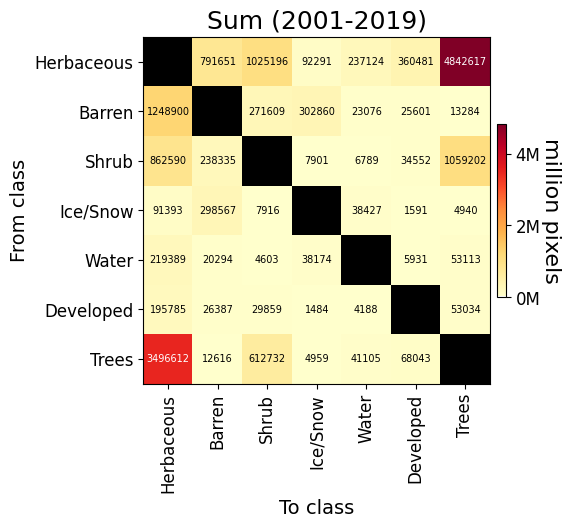

-> Saved heatmap: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/heatmap_sum_2001-2019.png


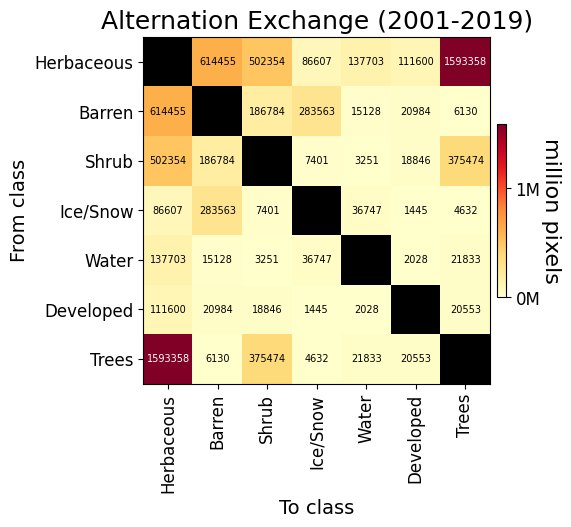

-> Saved heatmap: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/heatmap_alt_exc_2001-2019.png


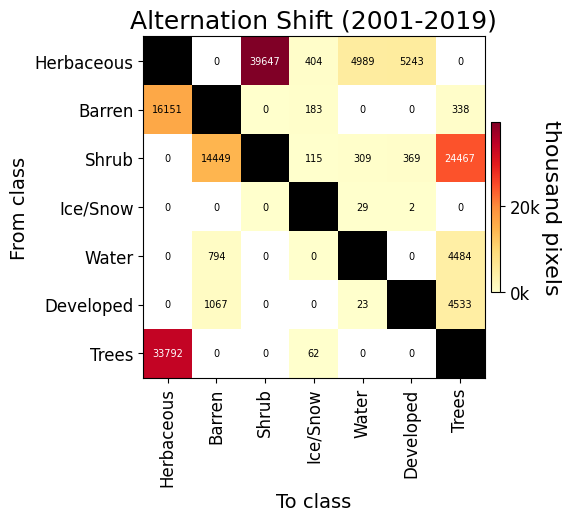

-> Saved heatmap: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/heatmap_alt_shift_2001-2019.png


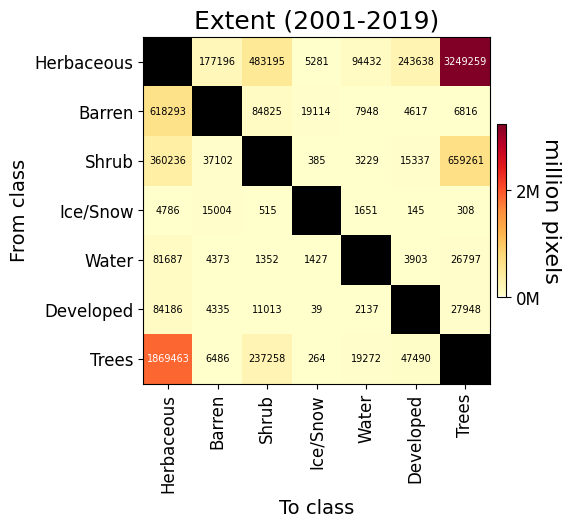

-> Saved heatmap: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/heatmap_ext_2001-2019.png


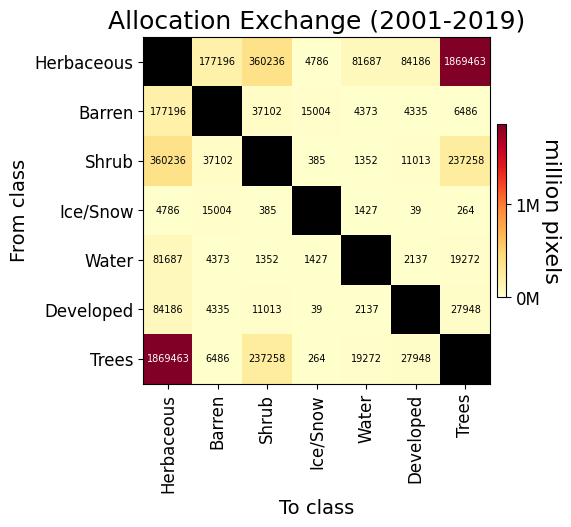

-> Saved heatmap: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/heatmap_all_exc_2001-2019.png


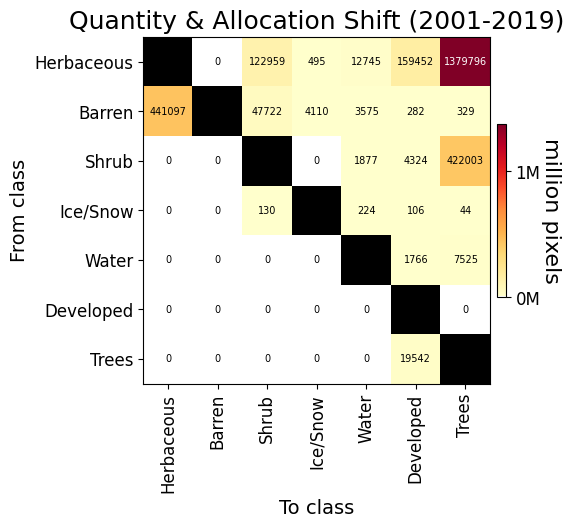

-> Saved heatmap: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/heatmap_qty_shift_2001-2019.png


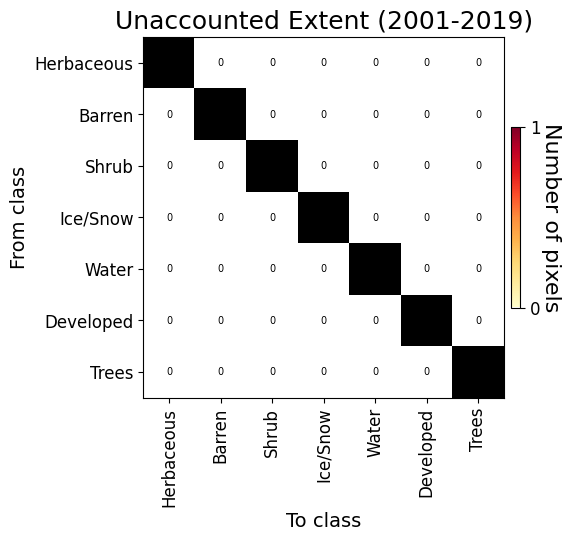

-> Saved heatmap: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/heatmap_unacc_ext_2001-2019.png


In [51]:
import importlib
import utils

importlib.reload(utils)

style_config = {
    "tick_fontsize_x": 12,
    "tick_fontsize_y": 12,
    "axis_label_fontsize": 14,
    "title_fontsize": 18,
    "ann_fontsize": 7,
    "cbar_fraction": 0.025,
    "cbar_pad": 0.02,
    "cbar_tick_labelsize": 12,
    "cbar_label_fontsize": 16,
    "cmap": "YlOrRd",
    "cell_size_inch": 0.8,
}

utils.generate_all_heatmaps(
    matrices_dict=matrices,
    output_path=base_drive_dir,
    interval_str=interval_str,
    years=years_to_process,
    style_config=style_config
)

## 6.5 Charts

### 6.5.1 Plot QUEST during Time Intervals chart

Generating change components during time intervals chart...


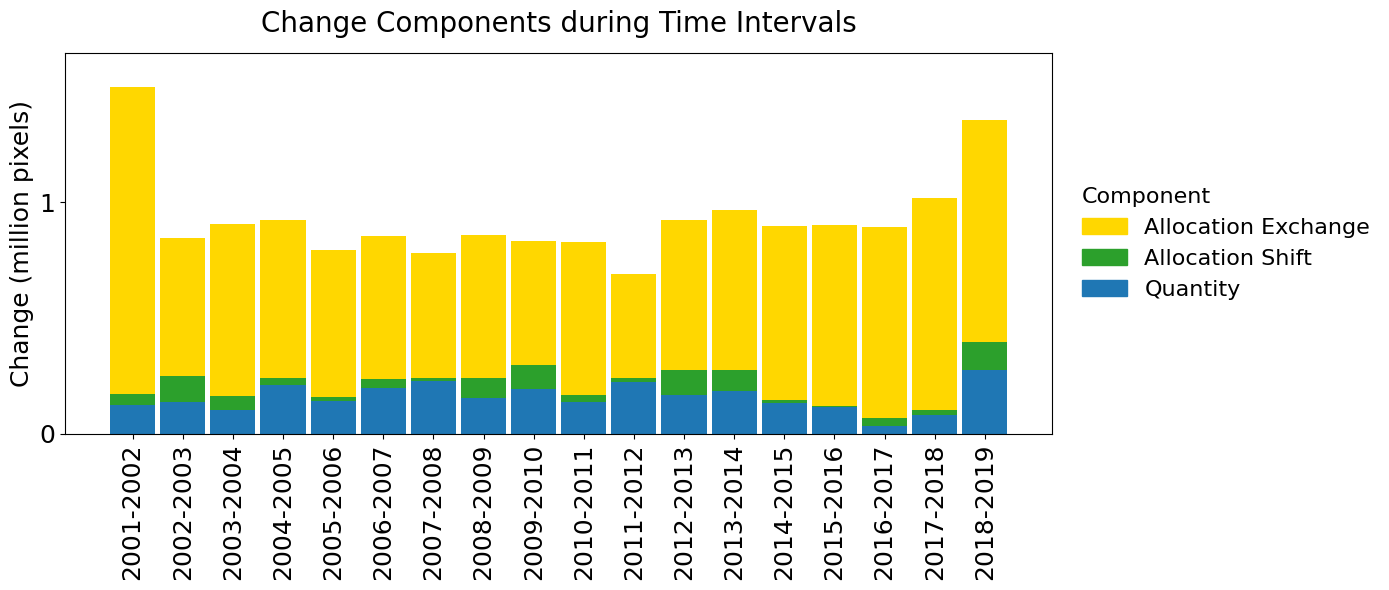

Chart saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/chart_change_components_time_interval.png


In [23]:
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Generating change components during time intervals chart...")

# Execute the plotting function
utils.plot_change_components_time_intervals(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
)

### 6.5.2 Plot QUEST Overall chart

Generating overall change components chart...


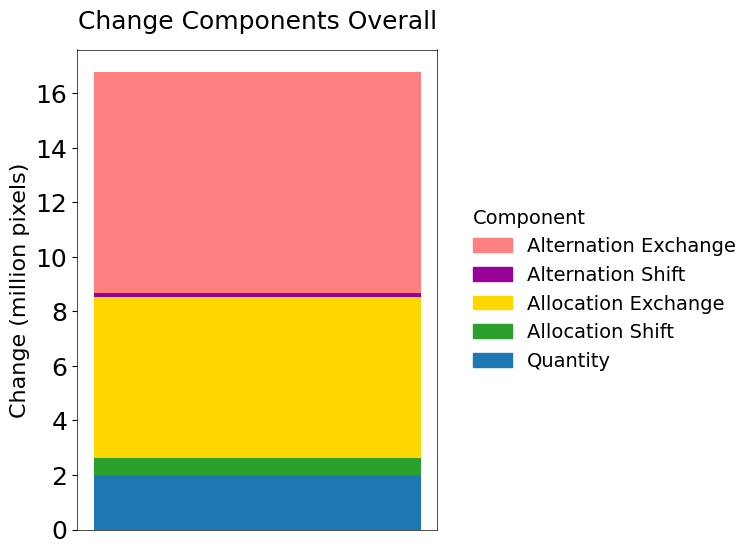

Chart saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/graphic_change_components_overall.png


In [24]:
import os
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Generating overall change components chart...")

# Specify paths and execute the plotting function
csv_components_path = os.path.join(
    base_drive_dir,
    "tables",
    "change_components.csv",
)

utils.plot_components_with_alternation(
    csv_path=csv_components_path,
    output_path=base_drive_dir,
)


### 6.5.3 Plot QUEST by Class chart

Generating change components by class chart...


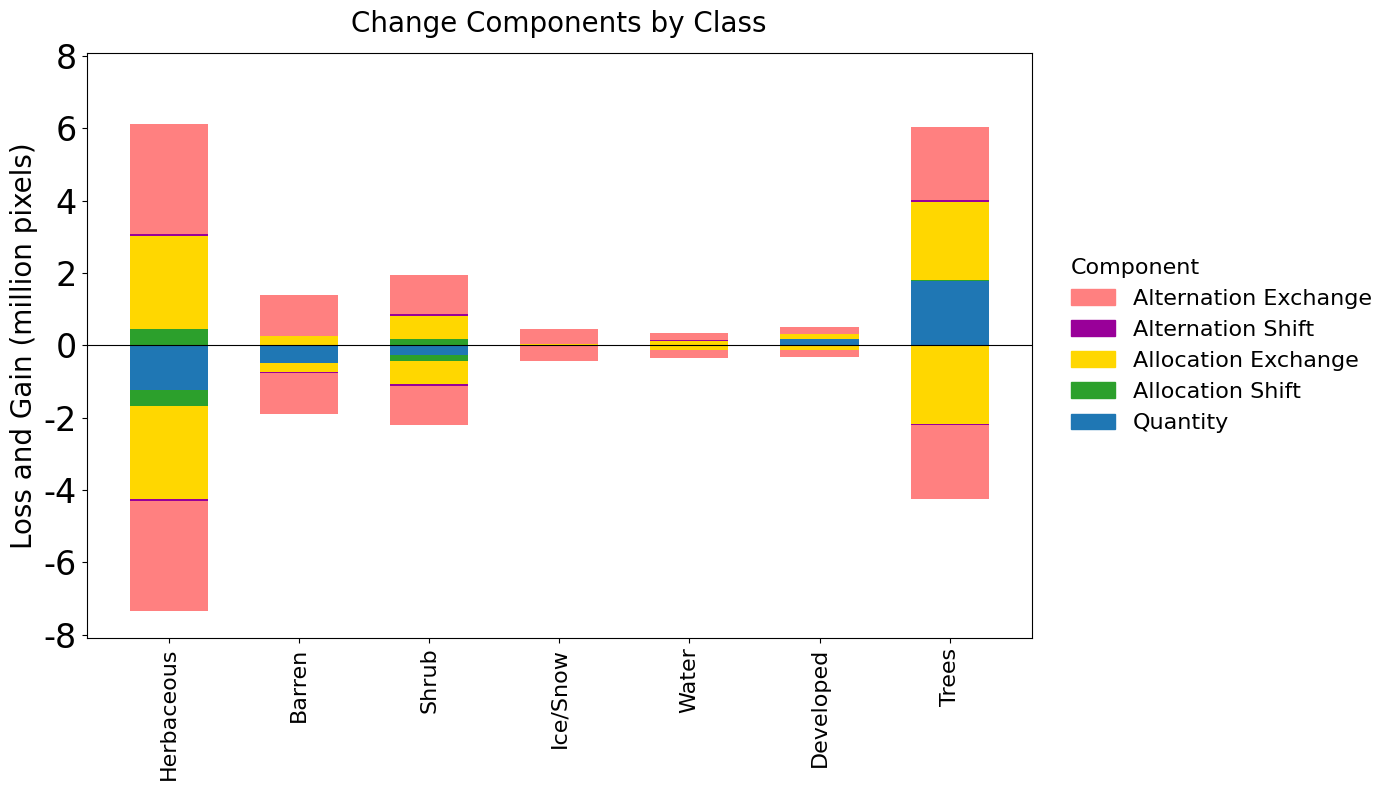

Chart saved to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/charts/chart_change_component_change_class.png


In [25]:
import importlib
import utils

# Reload utils to ensure the latest refactored functions are available
importlib.reload(utils)

print("Generating change components by class chart...")

# Execute the plotting function
utils.plot_change_components_by_class(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA
)


## 6.6 Maps

### 6.6.1 Export compute Extent map task to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the global configuration variables
print("Submitting Quantity Component Raster Task to GEE...")
quantity_raster_task = utils.export_quantity_component_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
    nodata_val=utils.NODATA_VALUE,
)
print("\nSuccess! You can monitor the progress in the GEE Tasks tab.")

### 6.6.2 Plot Extent Change map

Generating the global Extent Change map from GEE rasters...


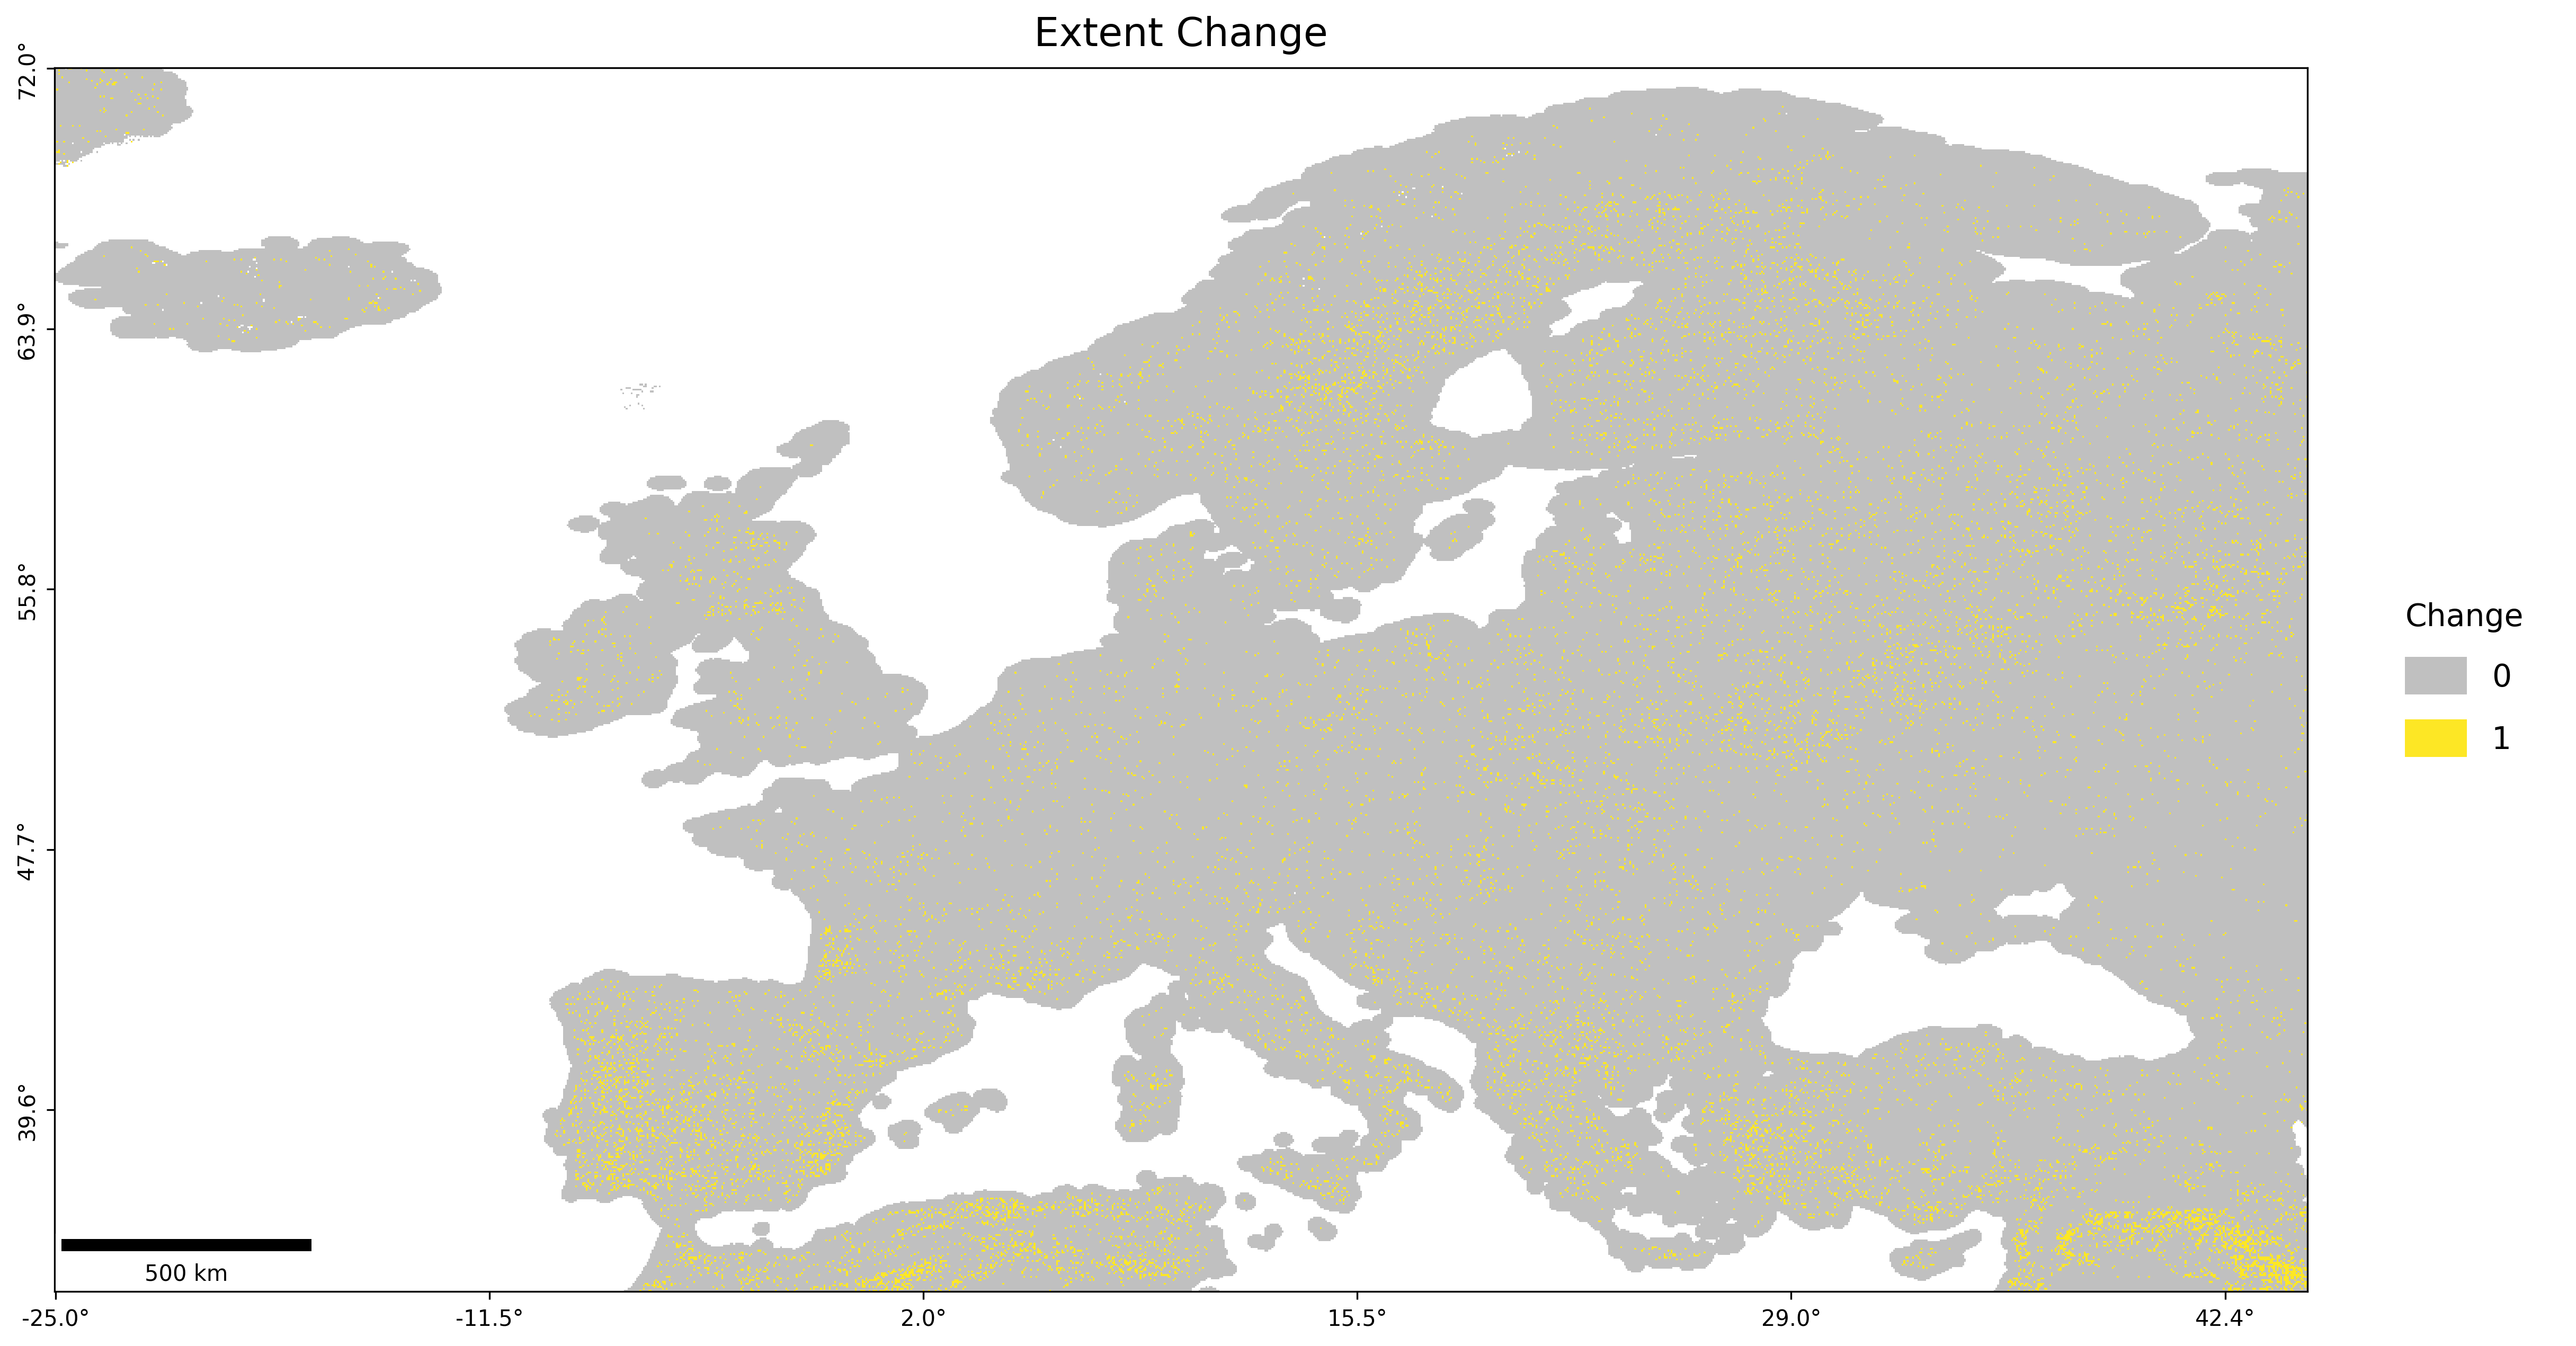

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/maps/map_extent_change.png


In [26]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function
print("Generating the global Extent Change map from GEE rasters...")
raster_prefix = f"Quantity_Component_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_quantity_component_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError running the function: {e}")

### 6.6.3 Export compute Alternation Exchange task to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the global configuration variables
print("Submitting Alternation Exchange Raster Task to GEE...")
exchange_raster_task = utils.export_alternation_exchange_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
    nodata_val=utils.NODATA_VALUE,
)
print("\nSuccess! You can monitor the progress in the GEE Tasks tab.")

###  6.6.4 Plot Alternation Exchange map

Generating the global Alternation Exchange map from GEE rasters...


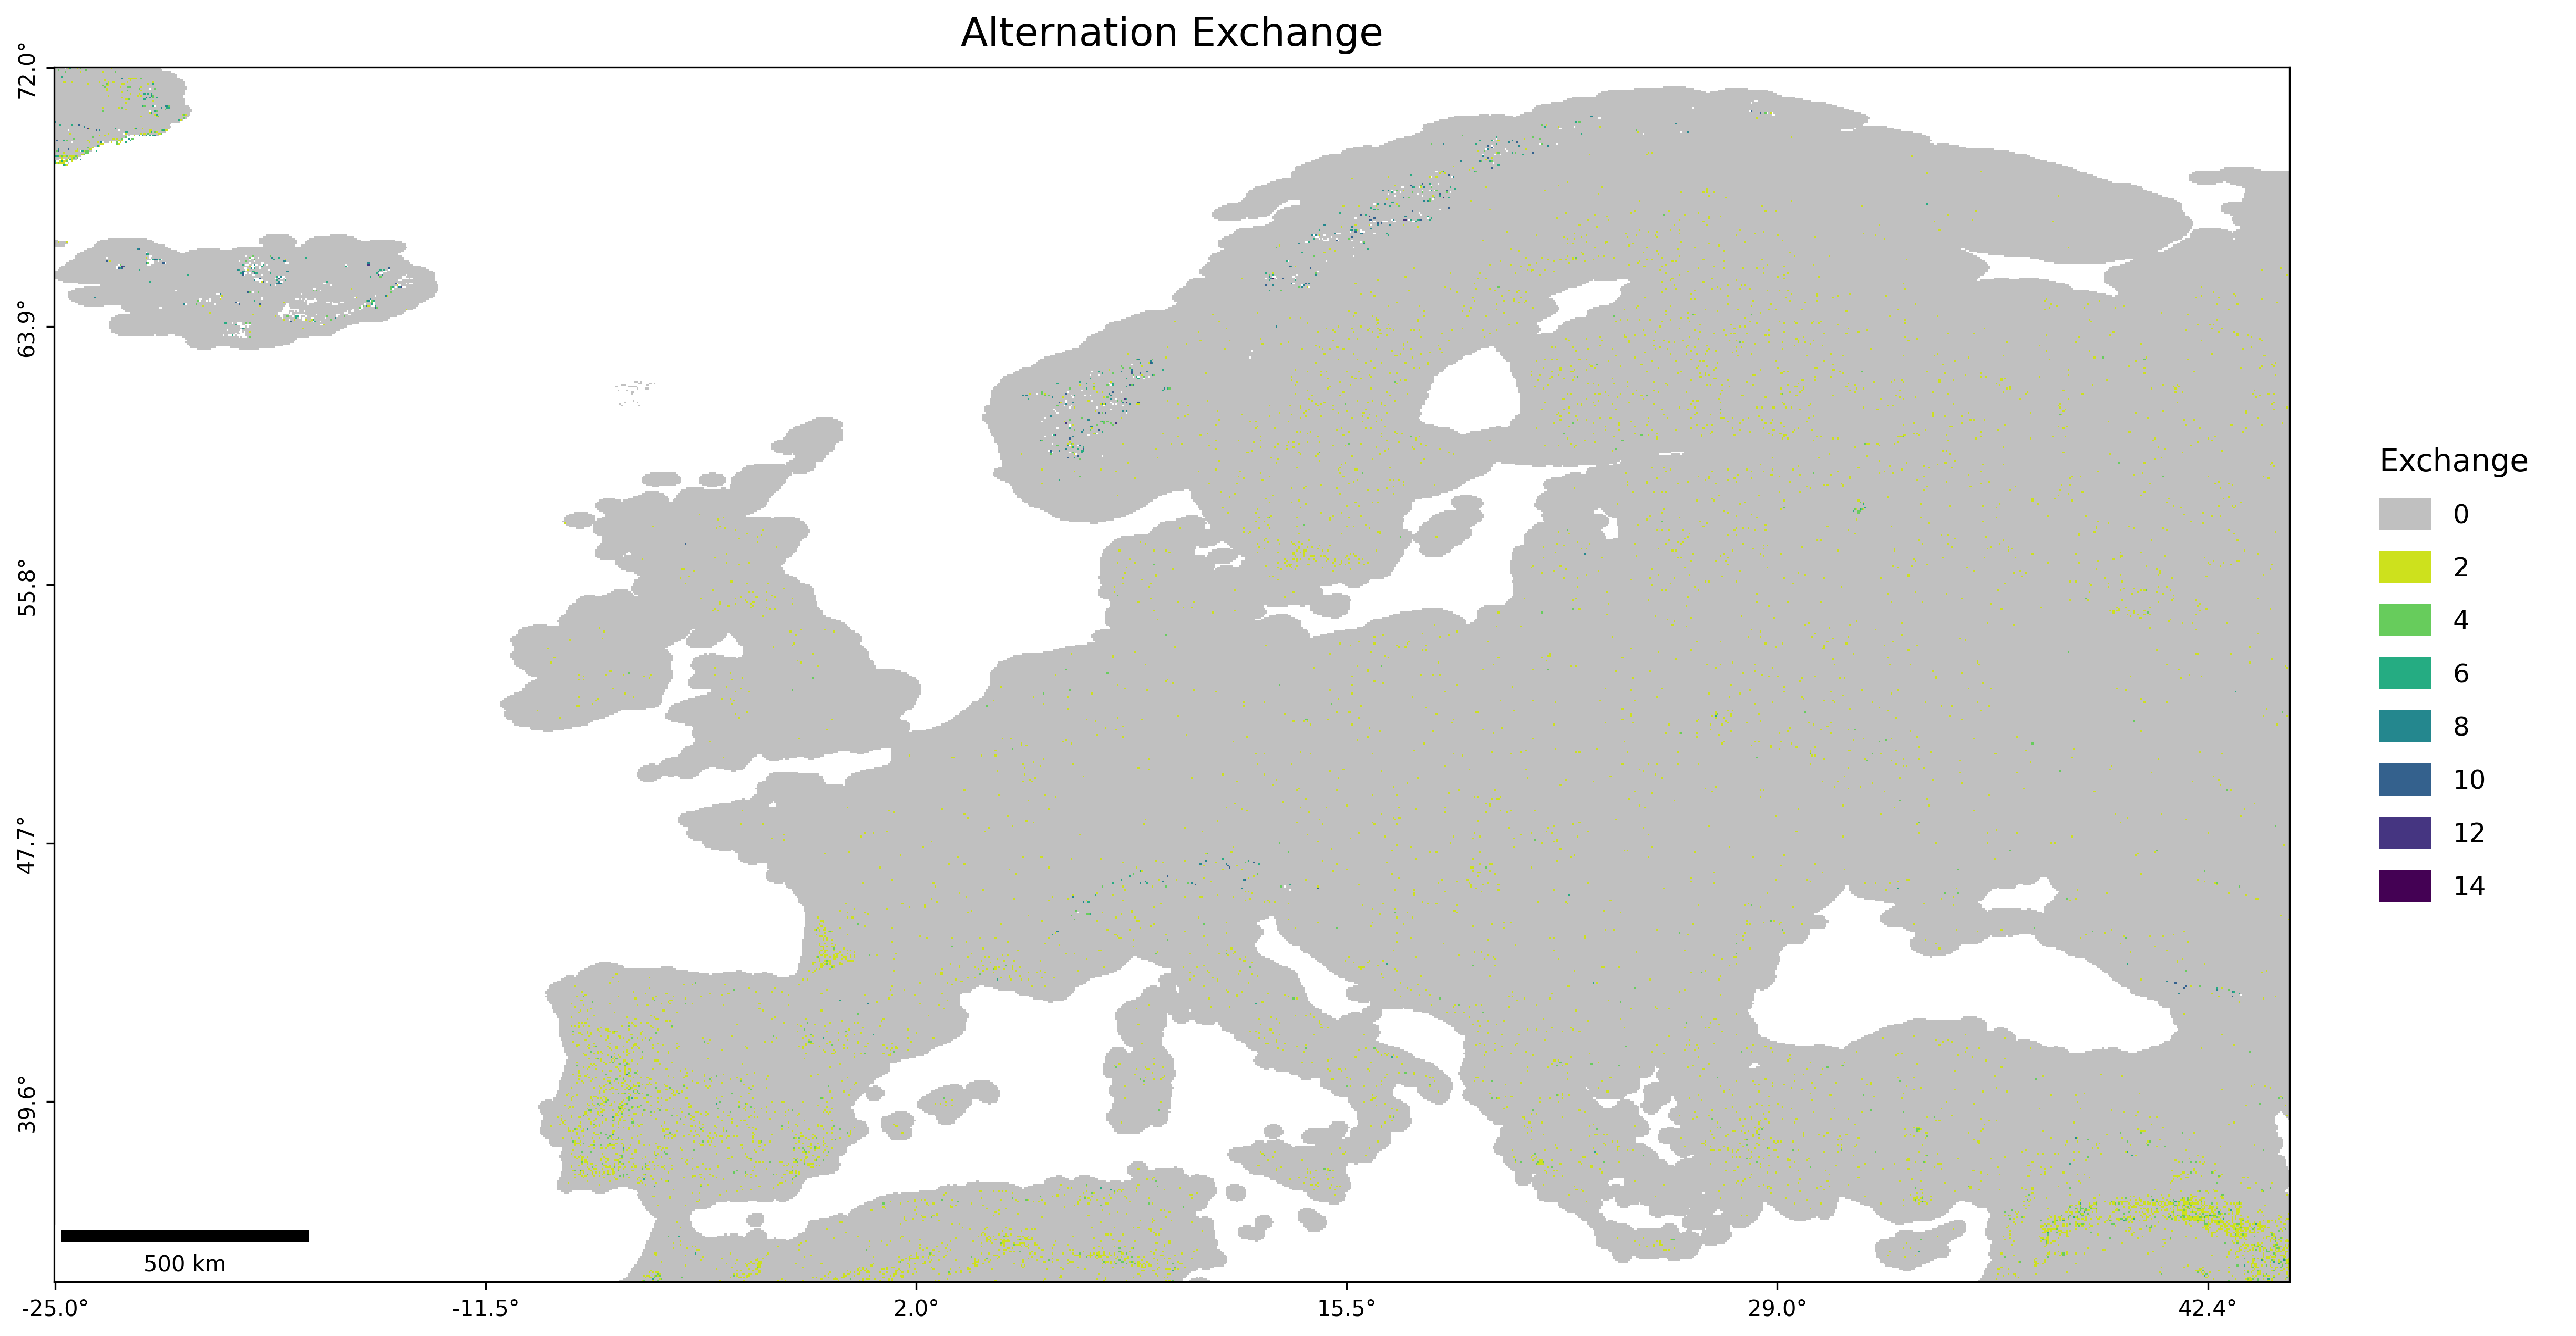

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/maps/map_alternation_exchange.png


In [27]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the global configuration variables
print("Generating the global Alternation Exchange map from GEE rasters...")
raster_prefix = f"Alternation_Exchange_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_alternation_exchange_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError running the function: {e}")

### 6.6.5 Export compute Alternation Shift task to GEE

In [ ]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function using the global configuration variables
print("Submitting Alternation Shift Raster Task to GEE...")
shift_raster_task = utils.export_alternation_shift_task_gee(
    year_list=years_to_process,
    drive_folder=gee_drive_folder,
    scale=spatial_resolution,
    nodata_val=utils.NODATA_VALUE,
)
print("\nSuccess! You can monitor the progress in the GEE Tasks tab.")

### 6.6.6 Plot Alternation Shift map

Generating the global Alternation Shift map from GEE rasters...


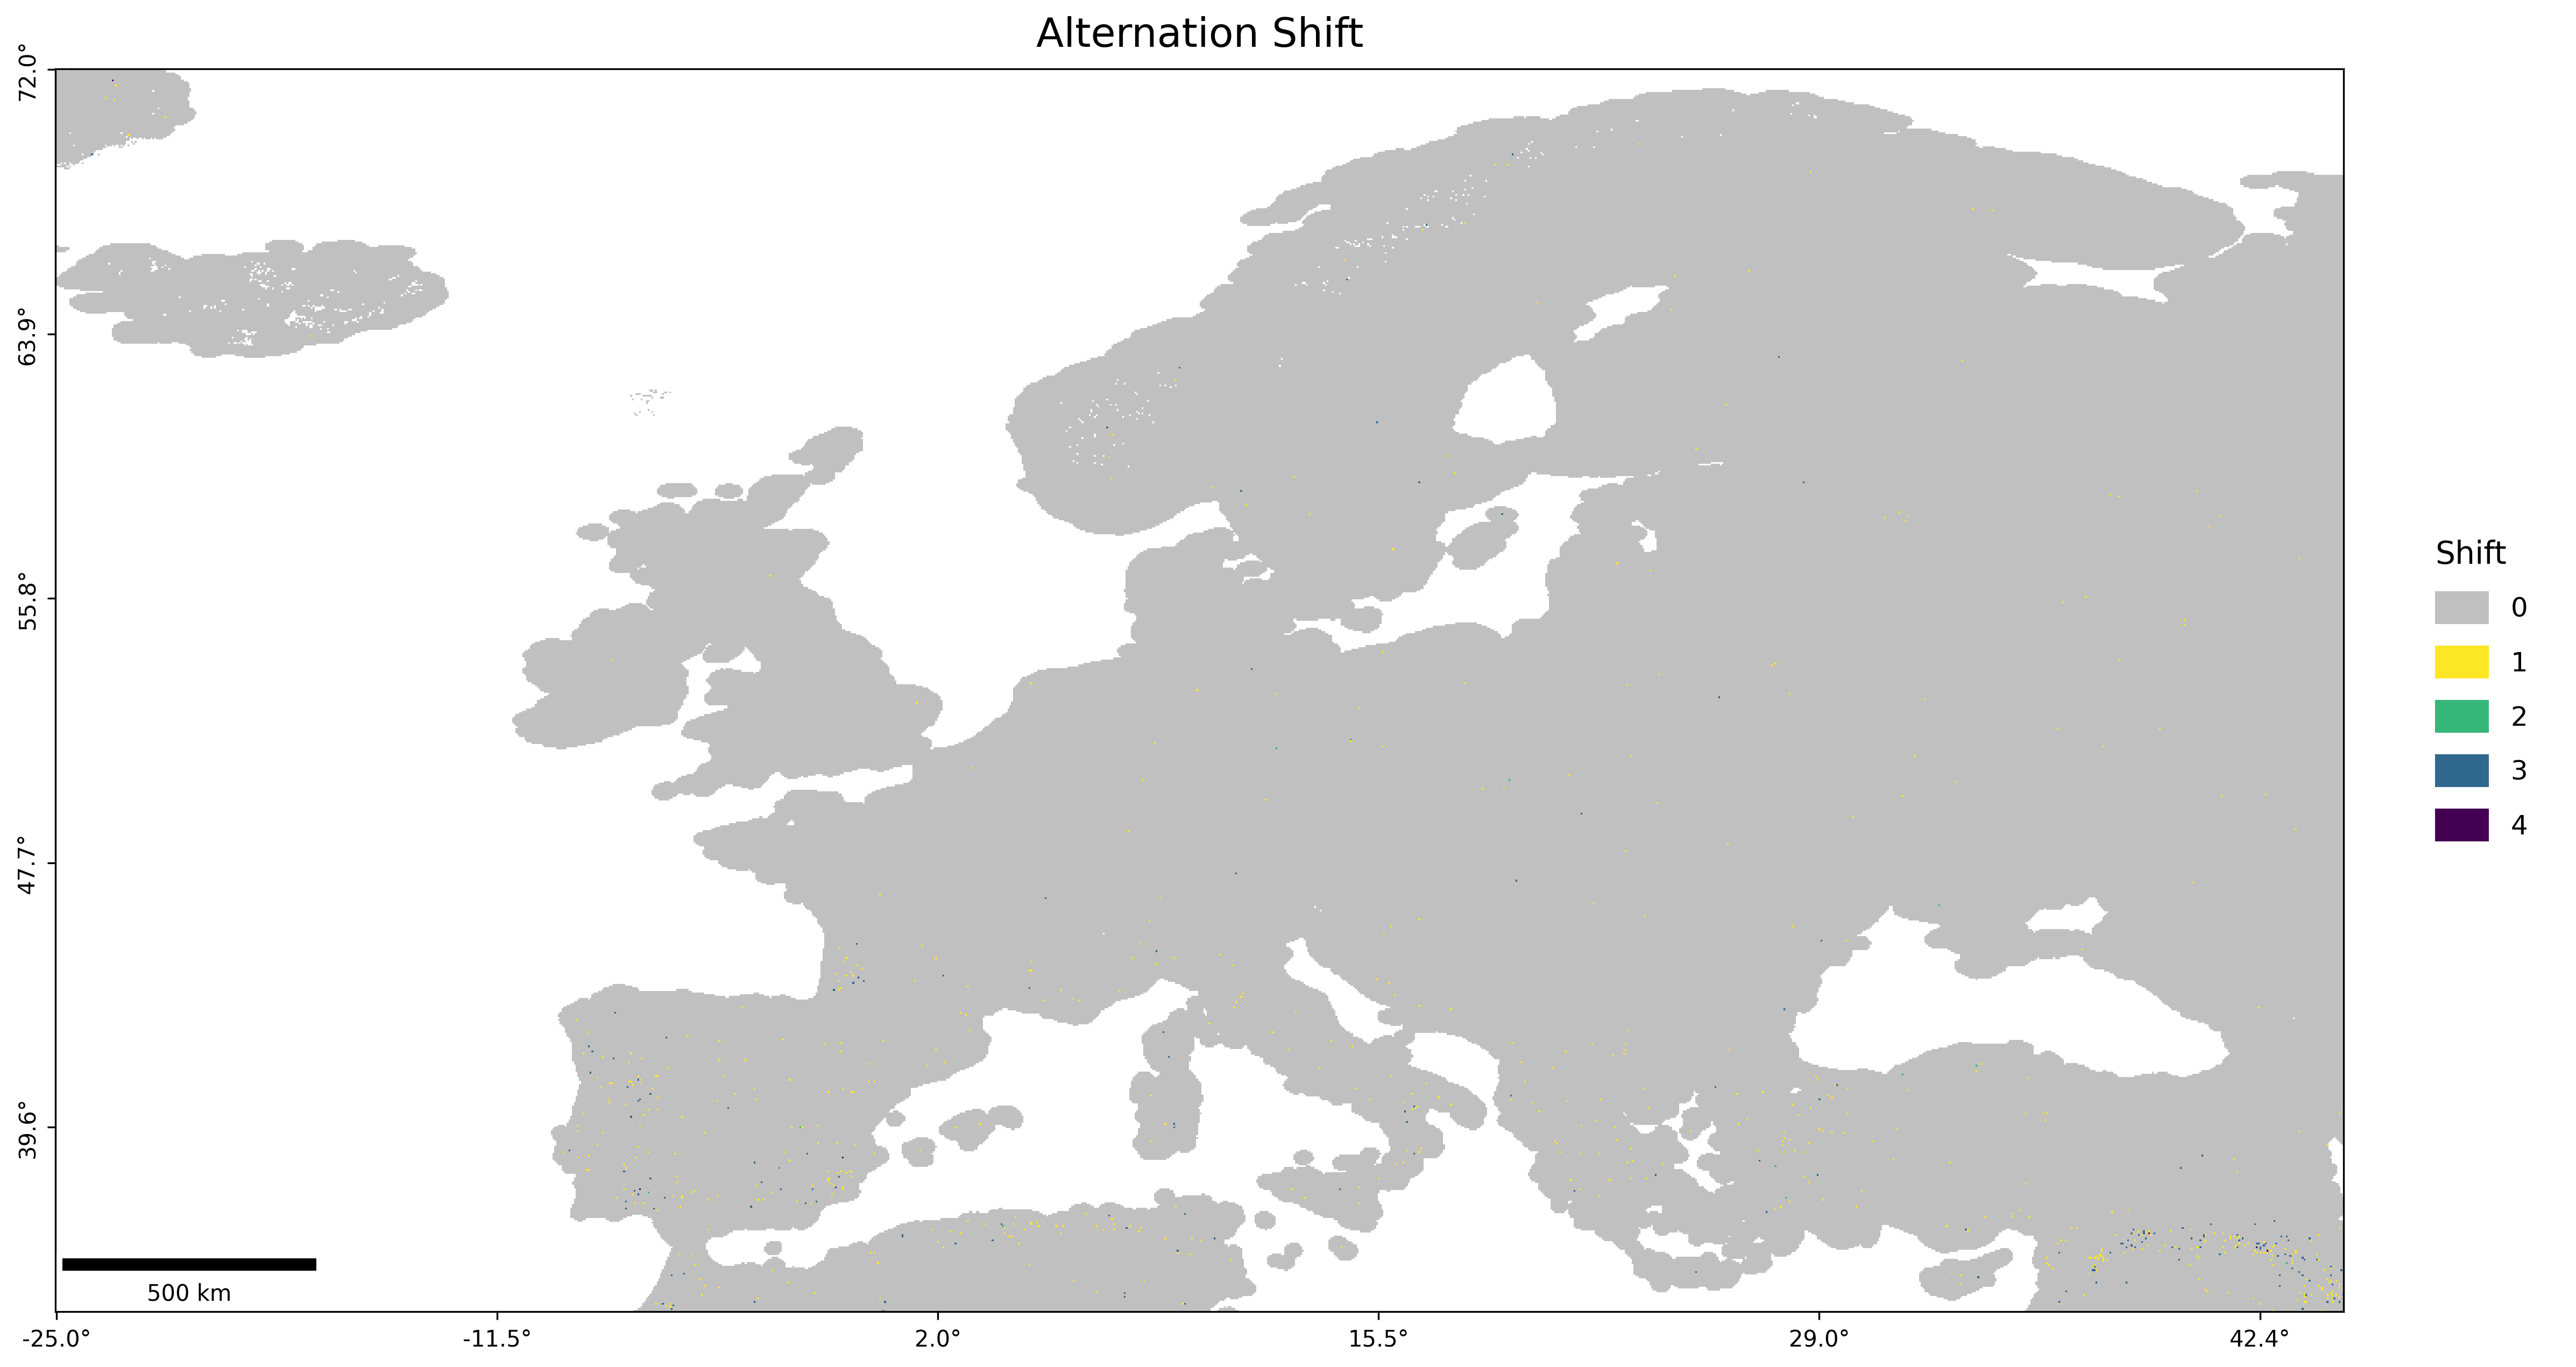

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_EU_30m_2001_to_2019/maps/map_alternation_shift.png


In [28]:
import importlib
import utils

# Reload utils to ensure the latest version is loaded
importlib.reload(utils)

# Execute the function
print("Generating the global Alternation Shift map from GEE rasters...")
raster_prefix = f"Alternation_Shift_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_alternation_shift_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError running the function: {e}")